# Analyse des erreurs — NLI4CT

Analyse poussée des prédictions (baseline vs finetuné) : quand et pourquoi le modèle se trompe, quand il réussit le mieux. Choix du **Prompt 1** ou **Prompt 2** et sauvegarde de toutes les figures dans un dossier pour rapport.


## 1. Configuration et chemins


In [1]:
# Choix du prompt : 1 (ancien) ou 2 (nouveau)
PROMPT_ID = 2  # Modifier ici pour analyser Prompt 1 ou Prompt 2

from pathlib import Path
import os

# Racine du projet NLI4CT (lancer le notebook depuis NLI4CT/ ou depuis la racine du repo)
NLI4CT_ROOT = Path(".").resolve()
if not (NLI4CT_ROOT / "results").exists():
    NLI4CT_ROOT = NLI4CT_ROOT / "NLI4CT"
if not (NLI4CT_ROOT / "results").exists():
    raise FileNotFoundError("Dossier results/ introuvable. Lancer le notebook depuis NLI4CT/ ou depuis la racine du dépôt.")

RESULTS_DIR = NLI4CT_ROOT / "results" / f"Prompt {PROMPT_ID}"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Fichiers JSON (données brutes) — à la racine NLI4CT
GOLD_TEST_JSON = NLI4CT_ROOT / "Gold_test.json"
# Prompt 1 peut utiliser Gold_test_formatted_old_prompt.jsonl selon le README
GOLD_TEST_JSONL = RESULTS_DIR / "Gold_test_formatted.jsonl"
if PROMPT_ID == 1 and (RESULTS_DIR / "Gold_test_formatted_old_prompt.jsonl").exists():
    GOLD_TEST_JSONL = RESULTS_DIR / "Gold_test_formatted_old_prompt.jsonl"

# CSV de prédictions : un seul fichier baseline et un seul finetuné par dossier
csv_baseline = list(RESULTS_DIR.glob("pred_bl_*.csv"))
csv_finetuned = list(RESULTS_DIR.glob("pred_ft_*.csv"))
CSV_BASELINE = csv_baseline[0] if csv_baseline else None
CSV_FINETUNED = csv_finetuned[0] if csv_finetuned else None

print(f"Prompt analysé : {PROMPT_ID}")
print(f"Résultats : {RESULTS_DIR}")
print(f"Figures  : {FIGURES_DIR}")
print(f"CSV baseline : {CSV_BASELINE}")
print(f"CSV finetuné: {CSV_FINETUNED}")
print(f"Gold test JSON: {GOLD_TEST_JSON.exists()}")
print(f"Gold test JSONL: {GOLD_TEST_JSONL.exists()}")


Prompt analysé : 2
Résultats : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Prompt 2
Figures  : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Prompt 2/figures
CSV baseline : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Prompt 2/pred_bl_qwen7b_NLI4CT_prompt2.csv
CSV finetuné: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Prompt 2/pred_ft_qwen7b_NLI4CT_prompt2.csv
Gold test JSON: True
Gold test JSONL: True


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10


## 2. Chargement des données


In [3]:
def extract_premise_hypothesis_from_user_content(text):
    """Extrait premise et hypothesis (statement) depuis le contenu user du JSONL."""
    if "HYPOTHESIS:" not in text:
        return text[:800] if len(text) > 800 else text, text[:500] if len(text) > 500 else text
    before_hyp, after_hyp = text.split("HYPOTHESIS:", 1)
    premise = before_hyp.replace("PREMISE:", "").strip()
    for sep in (".\n\nAnswer", "?\n\nAnswer", "? Answer", "\n\nAnswer"):
        if sep in after_hyp:
            after_hyp = after_hyp.split(sep)[0]
    statement = after_hyp.strip()
    return premise, statement

assert CSV_BASELINE and CSV_FINETUNED, "CSV baseline ou finetuné introuvables dans le dossier résultats."

df_baseline = pd.read_csv(CSV_BASELINE)
df_finetuned = pd.read_csv(CSV_FINETUNED)

for df in (df_baseline, df_finetuned):
    if df['is_correct'].dtype == object:
        df['is_correct'] = df['is_correct'].apply(lambda x: str(x).strip().lower() == 'true')

metadata_list = []
with open(GOLD_TEST_JSONL, 'r', encoding='utf-8') as f:
    for idx, line in enumerate(f):
        if not line.strip():
            continue
        obj = json.loads(line)
        msgs = obj.get("messages", [])
        if len(msgs) < 2:
            continue
        # Prompt 1 = [system, user, assistant], Prompt 2 = [user, assistant] → toujours prendre le message 'user' et le dernier (assistant)
        user_content = ""
        label = ""
        for m in msgs:
            if m.get("role") == "user":
                user_content = m.get("content", "")
            elif m.get("role") == "assistant":
                label = m.get("content", "").strip()
        premise, statement = extract_premise_hypothesis_from_user_content(user_content)
        metadata_list.append({'index': idx, 'type': 'N/A', 'section_id': 'N/A', 'premise_jsonl': premise, 'statement': statement, 'label': label})

if GOLD_TEST_JSON.exists():
    with open(GOLD_TEST_JSON, 'r', encoding='utf-8') as f:
        gold_data = json.load(f)
    keys = list(gold_data.keys())
    if len(keys) == len(metadata_list):
        for i in range(len(metadata_list)):
            e = gold_data[keys[i]]
            metadata_list[i]['type'] = e.get('Type', 'N/A')
            metadata_list[i]['section_id'] = e.get('Section_id', 'N/A')

df_metadata = pd.DataFrame(metadata_list)
df_baseline_merged = df_baseline.merge(df_metadata, on='index', how='left')
df_finetuned_merged = df_finetuned.merge(df_metadata, on='index', how='left')

# Utiliser premise/hypothesis du JSONL pour des longueurs fiables (le CSV peut être mal rempli)
for df in (df_baseline_merged, df_finetuned_merged):
    df['premise'] = df['premise_jsonl'].astype(str)
    df['hypothesis'] = df['statement'].astype(str)

# Longueurs (caractères) pour analyse prompt long/court
def safe_len(s):
    return len(str(s)) if pd.notna(s) else 0

for df in (df_baseline_merged, df_finetuned_merged):
    df['premise_len'] = df['premise'].apply(safe_len)
    df['hypothesis_len'] = df['hypothesis'].apply(safe_len)
    df['prompt_len'] = df['premise_len'] + df['hypothesis_len']

# Bins de longueur (tertiles) — robuste si beaucoup de longueurs identiques
def safe_length_bin(series):
    q = series.quantile([0, 1/3, 2/3, 1])
    edges = np.sort(q.unique())
    n_bins = max(1, len(edges) - 1)
    if n_bins == 1:
        return pd.Series('Moyen', index=series.index)
    labels = ['Court', 'Moyen', 'Long'][:n_bins]
    return pd.cut(series, bins=edges, labels=labels, include_lowest=True)
for df in (df_baseline_merged, df_finetuned_merged):
    df['length_bin'] = safe_length_bin(df['prompt_len'])

print(f"Baseline : {len(df_baseline_merged)} exemples")
print(f"Finetuné : {len(df_finetuned_merged)} exemples")
print(f"Métadonnées (type, section) : {df_metadata['type'].notna().all() and (df_metadata['section_id'] != 'N/A').all()}")


Baseline : 500 exemples
Finetuné : 500 exemples
Métadonnées (type, section) : True


## 3. Statistiques globales


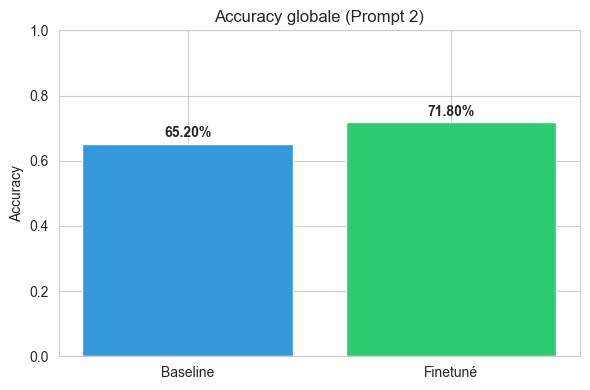

Baseline : 65.20%
Finetuné : 71.80%


In [4]:
acc_bl = df_baseline_merged['is_correct'].mean()
acc_ft = df_finetuned_merged['is_correct'].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Baseline', 'Finetuné'], [acc_bl, acc_ft], color=['#3498db', '#2ecc71'])
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_title(f'Accuracy globale (Prompt {PROMPT_ID})')
for i, v in enumerate([acc_bl, acc_ft]):
    ax.text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '01_accuracy_globale.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Baseline : {acc_bl:.2%}")
print(f"Finetuné : {acc_ft:.2%}")


## 4. Analyse par type de tâche (Single vs Comparison)


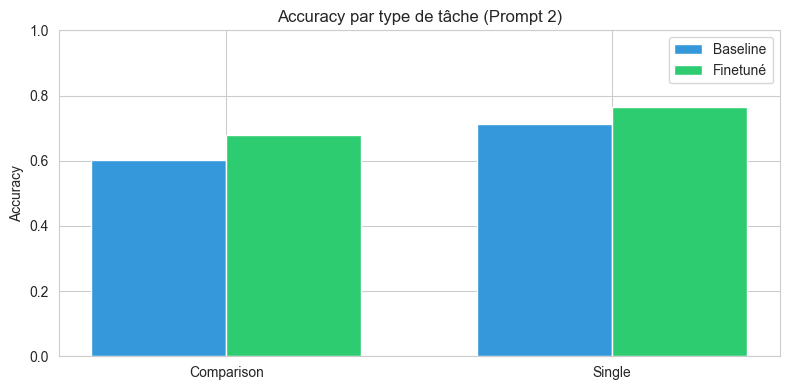

,n,correct,accuracy,model
type,,,,
Comparison,271,163,0.601476,Baseline
Single,229,163,0.711790,Baseline
Comparison,271,184,0.678967,Finetuné
Single,229,175,0.764192,Finetuné


In [5]:
def accuracy_by(df, col, model_name='Baseline'):
    g = df.groupby(col)
    n = g.size()
    correct = g['is_correct'].sum()
    return pd.DataFrame({'n': n, 'correct': correct}).assign(
        accuracy=lambda x: x['correct'] / x['n'], model=model_name)

acc_type_bl = accuracy_by(df_baseline_merged, 'type', 'Baseline')
acc_type_ft = accuracy_by(df_finetuned_merged, 'type', 'Finetuné')
acc_type = pd.concat([acc_type_bl, acc_type_ft])

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(acc_type_bl.index))
w = 0.35
ax.bar(x - w/2, acc_type_bl['accuracy'], w, label='Baseline', color='#3498db')
ax.bar(x + w/2, acc_type_ft['accuracy'], w, label='Finetuné', color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(acc_type_bl.index)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend()
ax.set_title(f'Accuracy par type de tâche (Prompt {PROMPT_ID})')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '02_accuracy_par_type.png', dpi=150, bbox_inches='tight')
plt.show()
display(acc_type)


## 5. Analyse par section du protocole


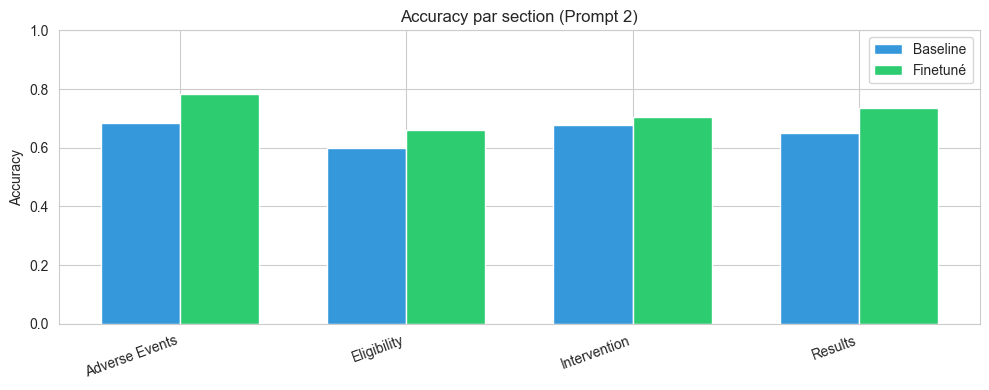

,n,correct,accuracy,model
section_id,,,,
Adverse Events,120,82,0.683333,Baseline
Eligibility,132,79,0.598485,Baseline
Intervention,142,96,0.676056,Baseline
Results,106,69,0.650943,Baseline
Adverse Events,120,94,0.783333,Finetuné
Eligibility,132,87,0.659091,Finetuné
Intervention,142,100,0.704225,Finetuné
Results,106,78,0.735849,Finetuné


In [6]:
acc_sec_bl = accuracy_by(df_baseline_merged, 'section_id', 'Baseline')
acc_sec_ft = accuracy_by(df_finetuned_merged, 'section_id', 'Finetuné')

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(acc_sec_bl.index))
w = 0.35
ax.bar(x - w/2, acc_sec_bl['accuracy'], w, label='Baseline', color='#3498db')
ax.bar(x + w/2, acc_sec_ft['accuracy'], w, label='Finetuné', color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(acc_sec_bl.index, rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend()
ax.set_title(f'Accuracy par section (Prompt {PROMPT_ID})')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '03_accuracy_par_section.png', dpi=150, bbox_inches='tight')
plt.show()
display(pd.concat([acc_sec_bl, acc_sec_ft]))


## 6. Analyse par longueur du prompt (court / moyen / long)

On regarde si les modèles se trompent davantage sur les **prompts longs** (prémisse + hypothèse plus longues) ou **courts**.


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_14298/3484080174.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(col)
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_14298/3484080174.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(col)


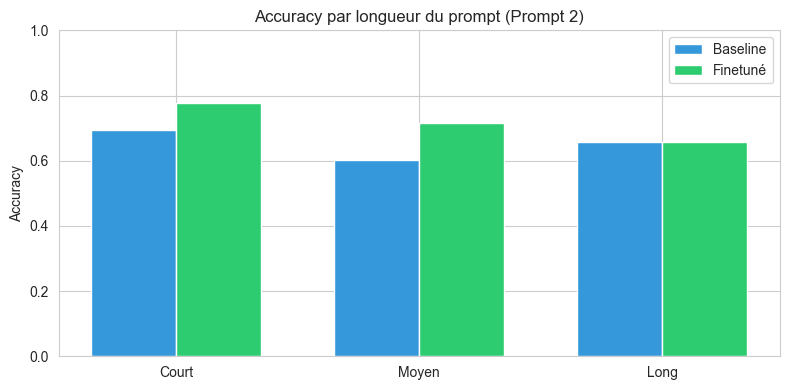

Effectifs par bin (baseline):
              n  correct  accuracy
length_bin                        
Court       167      116  0.694611
Moyen       166      100  0.602410
Long        167      110  0.658683

Effectifs par bin (finetuné):
              n  correct  accuracy
length_bin                        
Court       167      130  0.778443
Moyen       166      119  0.716867
Long        167      110  0.658683


In [7]:
acc_len_bl = accuracy_by(df_baseline_merged, 'length_bin', 'Baseline')
acc_len_ft = accuracy_by(df_finetuned_merged, 'length_bin', 'Finetuné')

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(acc_len_bl.index))
w = 0.35
ax.bar(x - w/2, acc_len_bl['accuracy'], w, label='Baseline', color='#3498db')
ax.bar(x + w/2, acc_len_ft['accuracy'], w, label='Finetuné', color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(acc_len_bl.index)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend()
ax.set_title(f'Accuracy par longueur du prompt (Prompt {PROMPT_ID})')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '04_accuracy_par_longueur.png', dpi=150, bbox_inches='tight')
plt.show()
print("Effectifs par bin (baseline):")
print(acc_len_bl[['n', 'correct', 'accuracy']])
print("\nEffectifs par bin (finetuné):")
print(acc_len_ft[['n', 'correct', 'accuracy']])


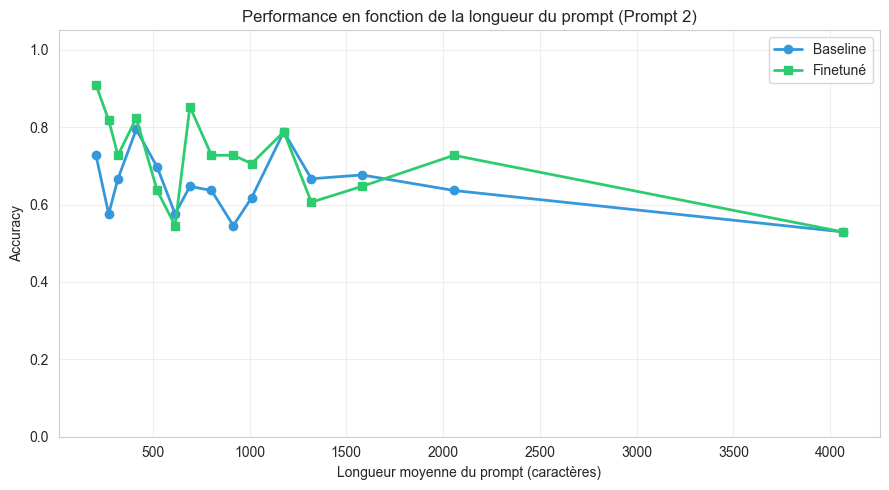

In [8]:
# Courbe : performance (accuracy) en fonction de la longueur du prompt
# Bins par *rang* de longueur (percentile) pour avoir toujours N_BINS points, même si les longueurs varient peu
N_BINS = 15
for df in (df_baseline_merged, df_finetuned_merged):
    df['len_bin_idx'] = (df['prompt_len'].rank(pct=True, method='first') * N_BINS).astype(int).clip(0, N_BINS - 1)

def accuracy_vs_length(df):
    g = df.groupby('len_bin_idx').agg(len_moy=('prompt_len', 'mean'), n=('prompt_len', 'count'), correct=('is_correct', 'sum'))
    g = g[g['n'] >= 1]
    g['accuracy'] = g['correct'] / g['n']
    return g.sort_index()

curve_bl = accuracy_vs_length(df_baseline_merged)
curve_ft = accuracy_vs_length(df_finetuned_merged)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curve_bl['len_moy'], curve_bl['accuracy'], 'o-', color='#3498db', label='Baseline', linewidth=2, markersize=6)
ax.plot(curve_ft['len_moy'], curve_ft['accuracy'], 's-', color='#2ecc71', label='Finetuné', linewidth=2, markersize=6)
ax.set_xlabel('Longueur moyenne du prompt (caractères)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title(f'Performance en fonction de la longueur du prompt (Prompt {PROMPT_ID})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '04b_accuracy_vs_longueur_courbe.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Quand le modèle se trompe

Distribution des **erreurs** : par type, section, longueur ; et type d'erreur (Entailment prédit Contradiction ou l'inverse).


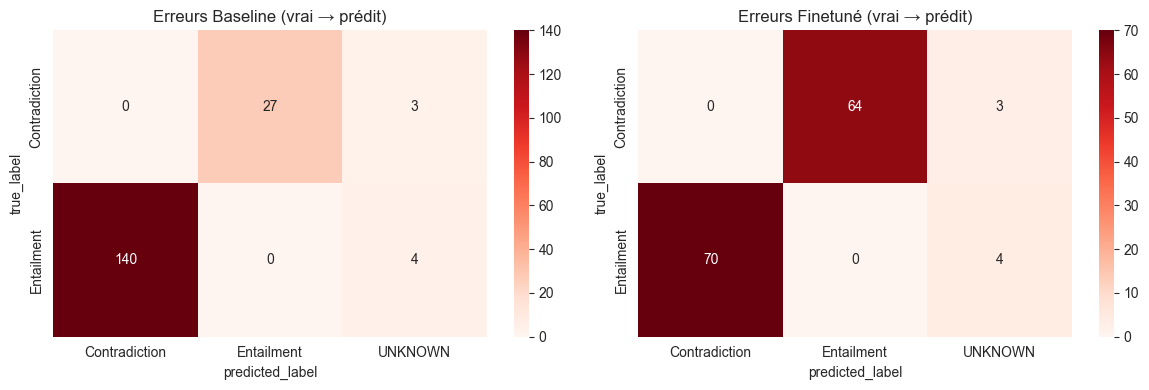

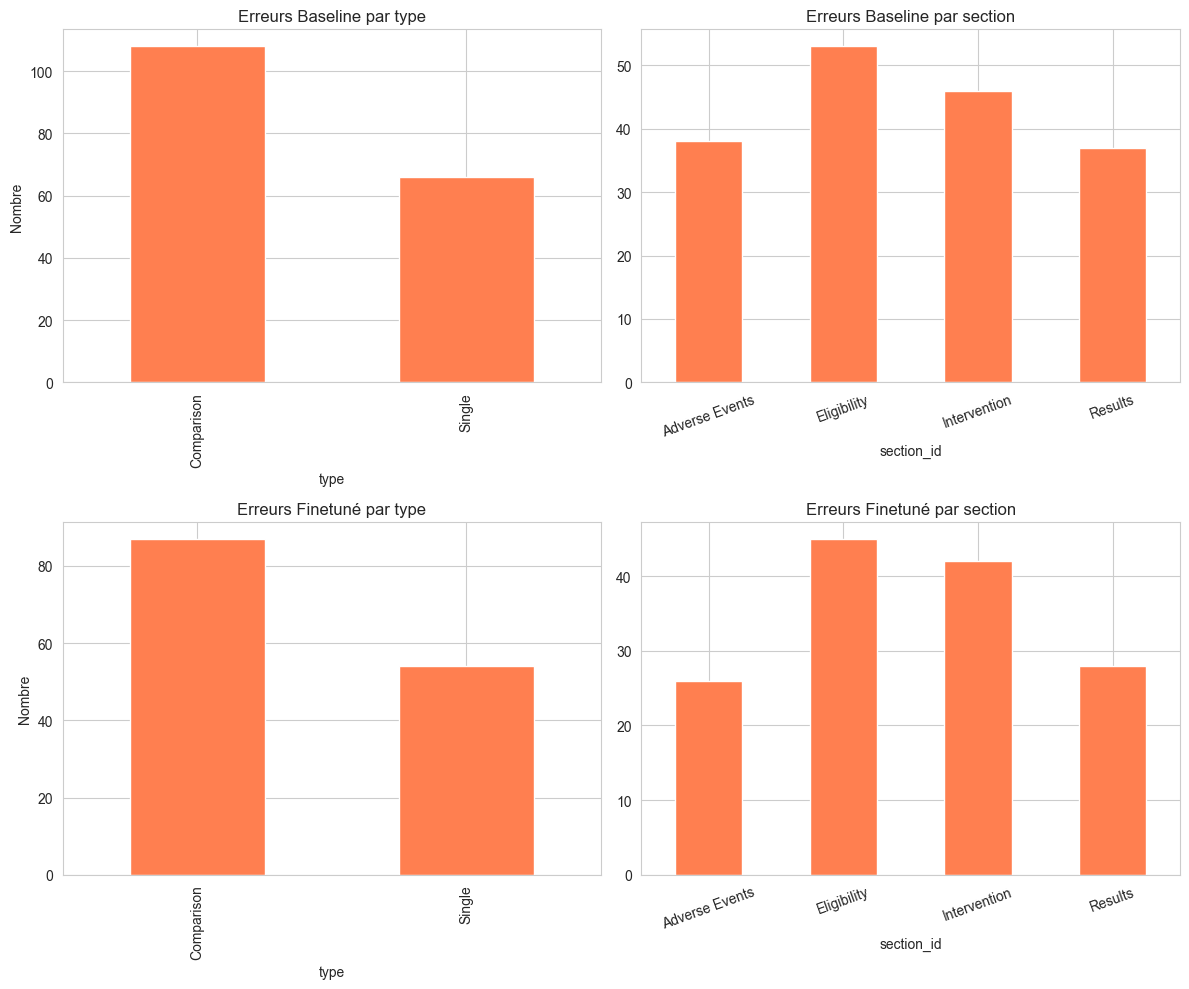

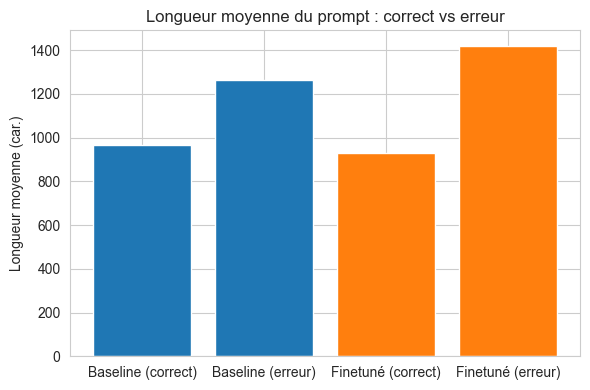

In [9]:
err_bl = df_baseline_merged[~df_baseline_merged['is_correct']]
err_ft = df_finetuned_merged[~df_finetuned_merged['is_correct']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (err, name) in zip(axes, [(err_bl, 'Baseline'), (err_ft, 'Finetuné')]):
    if len(err) > 0:
        c = err.groupby('true_label')['predicted_label'].value_counts().unstack(fill_value=0)
        sns.heatmap(c, annot=True, fmt='d', cmap='Reds', ax=ax)
    ax.set_title(f'Erreurs {name} (vrai → prédit)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '05_erreurs_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, (err, name) in enumerate([(err_bl, 'Baseline'), (err_ft, 'Finetuné')]):
    if len(err) > 0:
        err.groupby('type').size().plot(kind='bar', ax=axes[i, 0], color='coral')
        axes[i, 0].set_title(f'Erreurs {name} par type')
        axes[i, 0].set_ylabel('Nombre')
        err.groupby('section_id').size().plot(kind='bar', ax=axes[i, 1], color='coral')
        axes[i, 1].set_title(f'Erreurs {name} par section')
        axes[i, 1].tick_params(axis='x', rotation=20)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '06_erreurs_par_type_et_section.png', dpi=150, bbox_inches='tight')
plt.show()

# Longueur moyenne : erreurs vs corrects
fig, ax = plt.subplots(figsize=(6, 4))
for df, name in [(df_baseline_merged, 'Baseline'), (df_finetuned_merged, 'Finetuné')]:
    correct_len = df[df['is_correct']]['prompt_len'].mean()
    wrong_len = df[~df['is_correct']]['prompt_len'].mean()
    ax.bar([f'{name} (correct)', f'{name} (erreur)'], [correct_len, wrong_len], label=name)
ax.set_ylabel('Longueur moyenne (car.)')
ax.set_title('Longueur moyenne du prompt : correct vs erreur')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '07_longueur_erreurs_vs_corrects.png', dpi=150, bbox_inches='tight')
plt.show()


### 7b. Cas où le modèle n'a pas produit un label reconnu (UNKNOWN)

Quand le script d'évaluation ne trouve ni "Entailment" ni "Contradiction" dans les 50 premiers caractères de la sortie, le label est marqué **UNKNOWN**. Ci-dessous : les exemples concernés avec la sortie brute du modèle pour analyser le problème.

In [10]:
# Cas UNKNOWN : baseline et finetuné
unknown_bl = df_baseline_merged[df_baseline_merged['predicted_label'] == 'UNKNOWN']
unknown_ft = df_finetuned_merged[df_finetuned_merged['predicted_label'] == 'UNKNOWN']

print(f"Baseline : {len(unknown_bl)} cas UNKNOWN")
print(f"Finetuné : {len(unknown_ft)} cas UNKNOWN")

# Tableau détaillé : index, vrai label, sortie brute (raw_generated)
def show_unknown(df, name):
    if len(df) == 0:
        print(f"\nAucun cas UNKNOWN pour {name}.")
        return
    cols = ['index', 'true_label', 'type', 'section_id']
    if 'raw_generated' in df.columns:
        cols.append('raw_generated')
    display_df = df[cols].copy()
    if 'raw_generated' in df.columns:
        display_df['raw_generated'] = display_df['raw_generated'].str[:200] + ('...' if display_df['raw_generated'].str.len().gt(200).any() else '')
    display(display_df)

show_unknown(unknown_bl, 'Baseline')
show_unknown(unknown_ft, 'Finetuné')

# Sauvegarder les cas UNKNOWN dans un CSV pour analyse
unk_list = []
if len(unknown_bl) > 0:
    unk_list.append(unknown_bl[['index', 'true_label', 'type', 'section_id', 'premise', 'hypothesis']].assign(model='Baseline', raw=unknown_bl['raw_generated']))
if len(unknown_ft) > 0:
    unk_list.append(unknown_ft[['index', 'true_label', 'type', 'section_id', 'premise', 'hypothesis']].assign(model='Finetuné', raw=unknown_ft['raw_generated']))
if unk_list:
    unk_export = pd.concat(unk_list, ignore_index=True)
    unk_path = FIGURES_DIR / 'cas_unknown.csv'
    unk_export.to_csv(unk_path, index=False)
    print(f"\n>>> Cas UNKNOWN exportés : {unk_path}")

Baseline : 7 cas UNKNOWN
Finetuné : 7 cas UNKNOWN


,index,true_label,type,section_id,raw_generated
60,60,Entailment,Comparison,Eligibility,] except for those patients with a Karnofsky P...
112,112,Entailment,Single,Eligibility,"is not for metastatic disease, and provided th..."
134,134,Contradiction,Comparison,Eligibility,therapy (for up to 5 years)\n History of brea...
179,179,Contradiction,Comparison,Eligibility,"].\n Adequate bone marrow, liver, and kidney ..."
205,205,Entailment,Comparison,Eligibility,exposure.\n History of breast cancer with a p...
299,299,Contradiction,Single,Eligibility,is given for bone metastases only\n Presence ...
337,337,Entailment,Comparison,Eligibility,3 cycles of 5-fluorouracil (5-FU) or capecitab...


,index,true_label,type,section_id,raw_generated
60,60,Entailment,Comparison,Eligibility,]).\n Adequate bone marrow function as eviden...
112,112,Entailment,Single,Eligibility,is continued during trial treatment. Participa...
134,134,Contradiction,Comparison,Eligibility,replacement therapy\n History of breast cance...
179,179,Contradiction,Comparison,Eligibility,].\n Adequate organ function defined as follo...
205,205,Entailment,Comparison,Eligibility,replacement therapy and has 1 or more of the f...
299,299,Contradiction,Single,Eligibility,is continued during trial treatment and no dos...
337,337,Entailment,Comparison,Eligibility,2 prior chemotherapy regimens for unresectable...



>>> Cas UNKNOWN exportés : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Prompt 2/figures/cas_unknown.csv


## 8. Quand le modèle réussit le mieux

Profil des **réponses correctes** : types et sections où l'accuracy est la plus élevée ; cas où baseline et finetuné sont d'accord.


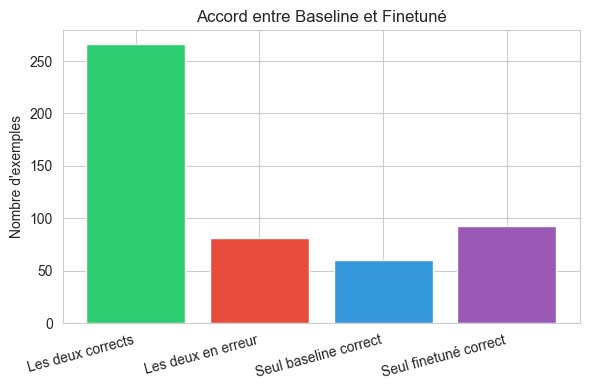

Sections où le finetuné a la meilleure accuracy :
                  n  correct  accuracy
section_id                            
Adverse Events  120       94  0.783333
Results         106       78  0.735849
Intervention    142      100  0.704225
Eligibility     132       87  0.659091


In [11]:
agree_both_correct = df_baseline_merged['is_correct'] & df_finetuned_merged['is_correct']
agree_both_wrong = ~df_baseline_merged['is_correct'] & ~df_finetuned_merged['is_correct']
only_bl = df_baseline_merged['is_correct'] & ~df_finetuned_merged['is_correct']
only_ft = ~df_baseline_merged['is_correct'] & df_finetuned_merged['is_correct']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Les deux corrects', 'Les deux en erreur', 'Seul baseline correct', 'Seul finetuné correct'],
       [agree_both_correct.sum(), agree_both_wrong.sum(), only_bl.sum(), only_ft.sum()],
       color=['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'])
ax.set_ylabel('Nombre d\'exemples')
ax.set_title('Accord entre Baseline et Finetuné')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '08_accord_baseline_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()

# Où le modèle (finetuné) est le plus fort : sections avec meilleure accuracy
print('Sections où le finetuné a la meilleure accuracy :')
print(acc_sec_ft.sort_values('accuracy', ascending=False)[['n', 'correct', 'accuracy']])


## 9. Régressions (baseline correct, finetuné incorrect)

Cas où le fine-tuning a **dégradé** la prédiction.


Nombre de régressions : 60
type
Comparison    36
Single        24
dtype: int64
section_id
Adverse Events    16
Eligibility       13
Intervention      19
Results           12
dtype: int64


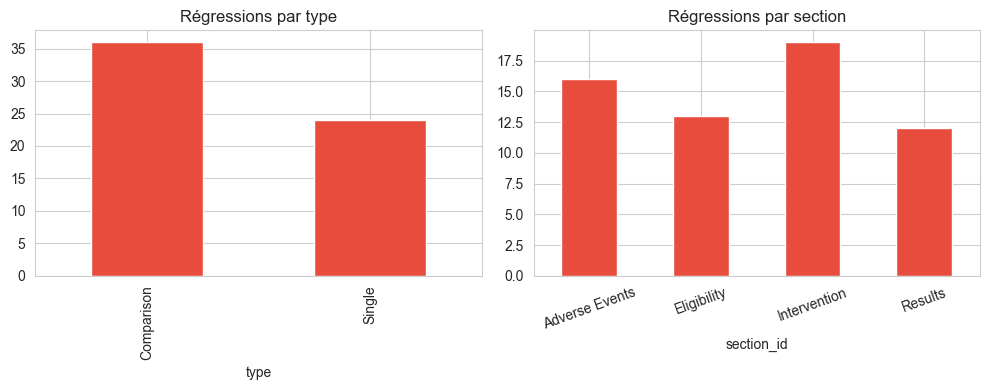

In [12]:
baseline_correct = df_baseline_merged['is_correct']
finetuned_wrong = ~df_finetuned_merged['is_correct']
regressions = df_baseline_merged[baseline_correct & finetuned_wrong].copy()

print(f"Nombre de régressions : {len(regressions)}")
if len(regressions) > 0:
    print(regressions.groupby('type').size())
    print(regressions.groupby('section_id').size())
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    regressions.groupby('type').size().plot(kind='bar', ax=axes[0], color='#e74c3c')
    axes[0].set_title('Régressions par type')
    regressions.groupby('section_id').size().plot(kind='bar', ax=axes[1], color='#e74c3c')
    axes[1].set_title('Régressions par section')
    axes[1].tick_params(axis='x', rotation=20)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '09_regressions_par_type_section.png', dpi=150, bbox_inches='tight')
    plt.show()


## 10. Améliorations (baseline incorrect, finetuné correct)

Cas où le fine-tuning a **amélioré** la prédiction.


Nombre d'améliorations : 93
type
Comparison    57
Single        36
dtype: int64
section_id
Adverse Events    28
Eligibility       21
Intervention      23
Results           21
dtype: int64


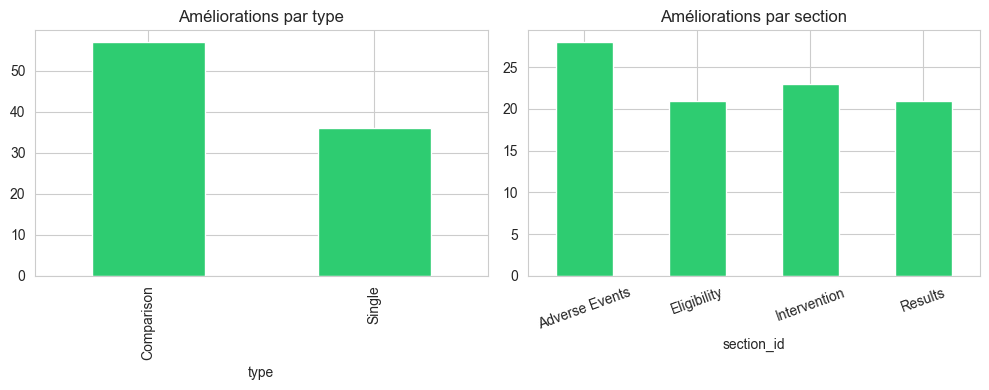

In [13]:
improvements = df_baseline_merged[~df_baseline_merged['is_correct'] & df_finetuned_merged['is_correct']].copy()

print(f"Nombre d'améliorations : {len(improvements)}")
if len(improvements) > 0:
    print(improvements.groupby('type').size())
    print(improvements.groupby('section_id').size())
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    improvements.groupby('type').size().plot(kind='bar', ax=axes[0], color='#2ecc71')
    axes[0].set_title('Améliorations par type')
    improvements.groupby('section_id').size().plot(kind='bar', ax=axes[1], color='#2ecc71')
    axes[1].set_title('Améliorations par section')
    axes[1].tick_params(axis='x', rotation=20)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '10_ameliorations_par_type_section.png', dpi=150, bbox_inches='tight')
    plt.show()


## 11. Exemples d'erreurs et de régressions

Quelques exemples pour **interpréter** pourquoi le modèle se trompe.


In [14]:
def get_section_description(sid):
    d = {'Eligibility': "Critères d'éligibilité", 'Intervention': 'Traitements',
         'Adverse Events': 'Effets secondaires', 'Results': 'Résultats'}
    return d.get(sid, sid)

if len(regressions) > 0:
    print('--- Exemples de régressions (baseline correct, finetuné faux) ---')
    for _, row in regressions.head(3).iterrows():
        idx = row['index']
        ft_pred = df_finetuned_merged.loc[df_finetuned_merged['index'] == idx, 'predicted_label'].iloc[0]
        print(f"\nIndex {idx} | Type: {row['type']} | Section: {row['section_id']}")
        print(f"  Vrai: {row['true_label']} | Baseline: {row['predicted_label']} | Finetuné: {ft_pred}")
        print(f"  Statement: {str(row['statement'])[:150]}...")

if len(improvements) > 0:
    print('\n--- Exemples d\'améliorations (baseline faux, finetuné correct) ---')
    for _, row in improvements.head(3).iterrows():
        idx = row['index']
        ft_pred = df_finetuned_merged.loc[df_finetuned_merged['index'] == idx, 'predicted_label'].iloc[0]
        print(f"\nIndex {idx} | Type: {row['type']} | Section: {row['section_id']}")
        print(f"  Vrai: {row['true_label']} | Baseline: {row['predicted_label']} | Finetuné: {ft_pred}")


--- Exemples de régressions (baseline correct, finetuné faux) ---

Index 1 | Type: Single | Section: Eligibility
  Vrai: Entailment | Baseline: Entailment | Finetuné: Contradiction
  Statement: There are no conditions on mental mental health, bodyweight, size of tumours, Karnofsky/ECOG score or Estimated life expectancy that need to be met in...

Index 6 | Type: Comparison | Section: Eligibility
  Vrai: Contradiction | Baseline: Contradiction | Finetuné: Entailment
  Statement: a patient that has received an organ transplant within the last month, and is still bedridden would be excluded from the primary trial but may be elig...

Index 21 | Type: Single | Section: Adverse Events
  Vrai: Contradiction | Baseline: Contradiction | Finetuné: Entailment
  Statement: in the primary trial there were 10 times the number of Hepatotoxicity cases as there were cases of hypertension and Pancreatectomy...

--- Exemples d'améliorations (baseline faux, finetuné correct) ---

Index 2 | Type: Compariso

## 12. Synthèse pour le rapport

Résumé rédigé : **dans quels cas le modèle se trompe** et **dans quels cas il est très bon**. Le fichier est sauvegardé dans le dossier figures pour inclusion au rapport.

In [15]:
# Synthèse : quand le modèle se trompe vs quand il est très bon (finetuné)
err_ft = df_finetuned_merged[~df_finetuned_merged['is_correct']]
correct_ft = df_finetuned_merged[df_finetuned_merged['is_correct']]

lines = [
    f"# Synthèse analyse d'erreurs — Prompt {PROMPT_ID}",
    "",
    "## Dans quels cas le modèle (finetuné) se trompe le plus",
    f"- Sections les plus difficiles : {err_ft.groupby('section_id').size().sort_values(ascending=False).head(3).to_dict()}",
    f"- Types les plus difficiles : {err_ft.groupby('type').size().sort_values(ascending=False).to_dict()}",
    f"- Longueur moyenne du prompt (car.) pour les erreurs : {err_ft['prompt_len'].mean():.0f}",
    f"- Longueur moyenne pour les corrects : {correct_ft['prompt_len'].mean():.0f}",
    "",
    "## Dans quels cas le modèle est très bon",
    f"- Sections avec la meilleure accuracy (finetuné) : {acc_sec_ft.nlargest(3, 'accuracy')['accuracy'].to_dict()}",
    f"- Types avec la meilleure accuracy : {acc_type_ft['accuracy'].to_dict()}",
    f"- Bins de longueur (finetuné) : {acc_len_ft['accuracy'].to_dict()}",
    f"- Nombre d'exemples où baseline et finetuné sont tous deux corrects : {agree_both_correct.sum()}",
    "",
    "## Régressions et améliorations",
    f"- Régressions (baseline correct, finetuné faux) : {len(regressions)}",
    f"- Améliorations (baseline faux, finetuné correct) : {len(improvements)}",
]
synthese_path = FIGURES_DIR / "synthese_erreurs.txt"
synthese_path.write_text("\n".join(lines), encoding="utf-8")
print("\n".join(lines))
print(f"\n>>> Synthèse sauvegardée : {synthese_path}")

# Synthèse analyse d'erreurs — Prompt 2

## Dans quels cas le modèle (finetuné) se trompe le plus
- Sections les plus difficiles : {'Eligibility': 45, 'Intervention': 42, 'Results': 28}
- Types les plus difficiles : {'Comparison': 87, 'Single': 54}
- Longueur moyenne du prompt (car.) pour les erreurs : 1420
- Longueur moyenne pour les corrects : 932

## Dans quels cas le modèle est très bon
- Sections avec la meilleure accuracy (finetuné) : {'Adverse Events': 0.7833333333333333, 'Results': 0.7358490566037735, 'Intervention': 0.704225352112676}
- Types avec la meilleure accuracy : {'Comparison': 0.6789667896678967, 'Single': 0.7641921397379913}
- Bins de longueur (finetuné) : {'Court': 0.7784431137724551, 'Moyen': 0.7168674698795181, 'Long': 0.6586826347305389}
- Nombre d'exemples où baseline et finetuné sont tous deux corrects : 266

## Régressions et améliorations
- Régressions (baseline correct, finetuné faux) : 60
- Améliorations (baseline faux, finetuné correct) : 93

>>> Synthèse 

## 13. Export des résultats détaillés


In [16]:
df_export = df_baseline_merged[['index', 'premise', 'hypothesis', 'true_label', 'premise_len', 'hypothesis_len', 'prompt_len', 'length_bin', 'type', 'section_id']].copy()
df_export['baseline_correct'] = df_baseline_merged['is_correct']
df_export['finetuned_correct'] = df_finetuned_merged['is_correct']
df_export['baseline_pred'] = df_baseline_merged['predicted_label']
df_export['finetuned_pred'] = df_finetuned_merged['predicted_label']
df_export['improvement'] = df_export['finetuned_correct'].astype(int) - df_export['baseline_correct'].astype(int)

out_csv = RESULTS_DIR / f'error_analysis_detailed_prompt{PROMPT_ID}.csv'
df_export.to_csv(out_csv, index=False)
print(f'Résultats détaillés sauvegardés : {out_csv}')
print(f'Figures sauvegardées dans : {FIGURES_DIR}')


Résultats détaillés sauvegardés : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Prompt 2/error_analysis_detailed_prompt2.csv
Figures sauvegardées dans : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Prompt 2/figures
